# 03 BMRA

Run BMRA based on global responses derived from the pathway activity predictions.

In [1]:
import pandas as pd
import numpy as np
import os
import bmra

In [2]:
cell_line = 'BC3C_dec'

data_dir =f'/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_bmra/blca_publication_OUTPUT_bmra_{cell_line}/'
data_dir_1 = os.path.join(data_dir, f'00_outputs_2020_{cell_line}/')
data_dir_2 = os.path.join(data_dir, f'01_outputs_2020_{cell_line}/')

info_dir =f"/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_LINCS/00_outputs_2020_{cell_line}/"

out_dir = os.path.join(data_dir,f'02_outputs_2020_{cell_line}/')


os.makedirs(out_dir, exist_ok = True)

## Load data

### Global responses

Assembled from global responses calculated from predicted pathway activities, and DPD global responses.

In [3]:
def assemble_R_global(pathway_rglobal_file, dpd_rglobal_file):
    """
    Assemble full R_global matrix
    """
    R_global_modules_df = pd.read_csv(pathway_rglobal_file, index_col = 0)

    perts = R_global_modules_df.columns.tolist()

    R_global_DPD_df = pd.read_csv(dpd_rglobal_file, index_col=0).T

    # filter by perts list
    R_global_DPD_df = R_global_DPD_df[R_global_DPD_df.index.isin(perts)]

    # sort by perts list
    R_global_DPD_df["sort_col"] = R_global_DPD_df.index.map({val: i for i, val in enumerate(perts)})
    R_global_DPD_df = R_global_DPD_df.sort_values("sort_col")
    R_global_DPD_df = R_global_DPD_df.drop("sort_col", axis = 1)

    # transpose
    R_global_DPD_df = R_global_DPD_df.T

    R_global_df = pd.concat([R_global_modules_df, R_global_DPD_df])

    return R_global_df

In [4]:
R_global_df = assemble_R_global(
    pathway_rglobal_file = os.path.join(data_dir_2, "R_global_annotated.csv"),
    dpd_rglobal_file = os.path.join(data_dir_1, "R_global_DPDonly_annotated.csv"),
)

modules = R_global_df.index.tolist()
exp_ids = R_global_df.columns.tolist()

R_global = R_global_df.values
n_modules = R_global.shape[0]

print(R_global.shape)
display(R_global_df)

(13, 106)


,ASG002_BC3C_24H:A10,ASG002_BC3C_24H:A11,ASG002_BC3C_24H:A19,ASG002_BC3C_24H:A20,ASG002_BC3C_24H:A21,ASG002_BC3C_24H:B10,ASG002_BC3C_24H:B11,ASG002_BC3C_24H:B14,ASG002_BC3C_24H:B15,ASG002_BC3C_24H:C13,...,SMAD_V11,SMAD_V12,SMAD_V13,SMAD_V14,SMAD_V15,SMAD_V16,SMAD_V17,SMAD_V18,SMAD_V19,SMAD_V20
CDK1_2,-0.759337,-0.552893,0.035743,0.020738,0.052145,-0.238840,-0.078586,-0.395800,0.155988,-0.009729,...,-0.377878,-0.354942,-0.326443,-0.341349,-0.316623,-0.329482,-0.323135,-0.351756,-0.352108,-0.376721
CDK4_6,0.004397,-0.089177,-0.280625,-0.119552,0.028854,-0.110051,-0.095499,-0.045004,-0.255722,0.009669,...,0.242802,0.237798,0.207971,0.187998,0.172693,0.183798,0.212493,0.202204,0.237615,0.206721
EGFR,0.603534,0.513122,0.221285,0.381010,0.550584,0.128331,-0.446104,0.263245,0.283416,-0.023016,...,-1.336891,-0.871765,-0.860751,-0.740957,-0.712548,-0.728234,-0.786046,-0.961295,-0.937902,-0.993657
Estrogen,-0.192528,-0.298931,-0.285204,-0.502063,-0.988345,-0.325069,-0.088520,-0.358271,-0.237663,-0.053975,...,-0.290522,-0.266001,-0.240539,-0.266603,-0.251130,-0.257604,-0.230746,-0.277320,-0.258642,-0.303482
FGFR,-0.113130,-0.196413,-0.099669,0.065474,-0.034717,-0.436489,-0.028167,-0.065509,-0.073538,-0.295952,...,-0.904925,-0.739046,-0.677600,-0.680026,-0.608209,-0.660743,-0.665450,-0.753880,-0.762342,-0.839164
PI3K,-1.943895,-1.863624,-1.682186,-1.419462,-0.621484,-0.177640,-0.008272,-0.483758,-1.375115,-0.237255,...,-0.132020,-0.075732,-0.030197,-0.066946,-0.040962,-0.082623,-0.053640,-0.085105,-0.085941,-0.166477
p53,-0.262849,-0.328878,-0.085118,-0.341063,0.031426,-1.805482,-1.719131,-0.118219,-0.070057,-1.551187,...,0.056287,0.035891,0.048544,0.051309,0.023335,0.051762,0.073851,0.032916,0.075177,0.039925
TOP2A,-0.292842,0.071317,-0.202687,-0.184436,-0.133276,0.019082,0.012915,-1.998258,-0.251282,-0.389292,...,0.153661,0.143817,0.135635,0.113246,0.102625,0.130764,0.141249,0.127625,0.152532,0.145638
Src,-1.055460,-1.990811,0.580747,-1.501162,0.615131,-1.374638,0.537907,0.456359,0.457399,0.499039,...,-0.111272,-0.141251,-0.086139,-0.115508,-0.045002,-0.106340,-0.086825,-0.100296,-0.142246,-0.152101
SMAD3,0.021151,-0.116255,0.031533,-0.348121,0.057626,0.081111,0.026304,0.136905,0.140040,0.061714,...,-0.898236,-0.822701,-0.785937,-0.814870,-0.780934,-0.790786,-0.776757,-0.841006,-0.825758,-0.878606


In [5]:
print(R_global_df.values.min())
print(R_global_df.values.max())

-1.999290281257477
1.266216428290639


### Perturbation matrix

In [6]:
inhib_conc_df = pd.read_csv(os.path.join(data_dir_1, "inhib_conc_annotated.csv"), index_col = 0)
#LFC_PLCg = pd.read_csv(os.path.join(info_dir,"PLCg_Data_log_2020.csv"),index_col=0)
#inhib_conc = inhib_conc_df.drop(columns=LFC_PLCg.index).values
inhib_conc = inhib_conc_df.values

n_DPDs = R_global.shape[0] - inhib_conc.shape[0]

pert_modules = np.where(inhib_conc != 0, 1, 0)
pert_DPD = np.zeros((n_DPDs, len(exp_ids)))

pert = np.vstack([pert_modules, pert_DPD])

print(pert.shape)
print(pert)

(13, 106)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Networks

In [7]:
# empty prior
#G_prior = np.zeros((n_modules, n_modules))
G_prior_df = pd.read_excel('//home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_LINCS/00_outputs_2020_BC3C_dec/ALL_DATA_2020_post.xlsx',sheet_name = "prior_net_work" , index_col = 0)

G_prior = G_prior_df.values
G_prior_df

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0,0,0,0,0,0,0,0,0,0,0,0,0
CDK4_6,0,0,0,0,0,0,0,0,0,0,0,0,0
EGFR,0,0,0,0,0,0,0,0,0,0,0,0,0
Estrogen,0,0,0,0,0,0,0,0,0,0,0,0,0
FGFR,0,0,0,0,0,0,0,0,0,0,0,0,0
PI3K,0,0,0,0,0,0,0,0,0,0,0,0,0
p53,0,0,0,0,0,0,0,0,0,0,0,0,0
TOP2A,0,0,0,0,0,0,0,0,0,0,0,0,0
Src,0,0,0,0,0,0,0,0,0,0,0,0,0
SMAD3,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
#G_prior_r_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020.xlsx"), sheet_name = "prior_r", index_col = 0)

#G_prior_r = G_prior_r_df.values
#G_prior_r_df

In [9]:
G_not = np.eye(n_modules)
G_not[:, n_modules - n_DPDs :] = 1

G_not

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.]])

## Run BMRA

In [10]:
n_gibbs = 200_000
n_window = 5_000

mode = "all"
n_iterations = 1

In [11]:
A_mean, A_sd, r_mean, r_sd = bmra.run_bmra(R_global,
            pert,
            G_prior,
            G_not,
            #r_prior = G_prior_r,
            n_gibbs = n_gibbs,
            n_window = n_window,
            mode = mode,
            n_iterations = n_iterations,
        )

A_mean_df = pd.DataFrame(A_mean, index = modules, columns = modules)
A_sd_df = pd.DataFrame(A_sd, index = modules, columns = modules)
r_mean_df = pd.DataFrame(r_mean, index = modules, columns = modules)
r_sd_df = pd.DataFrame(r_sd, index = modules, columns = modules)

display(A_mean_df)
display(A_sd_df)
display(r_mean_df)
display(r_sd_df)

A_mean_df.to_csv(os.path.join(out_dir, "A_mean.csv"))
A_sd_df.to_csv(os.path.join(out_dir, "A_sd.csv"))
r_mean_df.to_csv(os.path.join(out_dir, "r_mean.csv"))
r_sd_df.to_csv(os.path.join(out_dir, "r_sd.csv"))

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0.0,0.000177,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.205224,0.000000,0.0,0.0,0.0
CDK4_6,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.0
EGFR,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.721902,1.000000,0.0,0.0,0.0
Estrogen,0.0,0.008384,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0
FGFR,0.0,0.000000,1.000000,0.000000,0.000000,1.000000,0.053619,0.000000,0.000000,1.000000,0.0,0.0,0.0
PI3K,1.0,0.000000,0.626633,1.000000,0.000000,0.000000,0.002830,1.000000,0.913384,0.006268,0.0,0.0,0.0
p53,0.0,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.033875,0.0,0.0,0.0
TOP2A,0.0,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.0,0.000000,1.000000,0.000000,0.000000,0.000923,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0.000000e+00,0.013301,1.332268e-15,0.000000e+00,1.332268e-15,1.332268e-15,0.000000e+00,0.000000e+00,4.038649e-01,0.000000e+00,0.0,0.0,0.0
CDK4_6,0.000000e+00,0.000000,0.000000e+00,1.110223e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.110223e-15,0.0,0.0,0.0
EGFR,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,3.330669e-16,3.330669e-16,0.000000e+00,0.000000e+00,4.480617e-01,3.330669e-16,0.0,0.0,0.0
Estrogen,0.000000e+00,0.091179,0.000000e+00,0.000000e+00,1.665335e-15,1.665335e-15,0.000000e+00,0.000000e+00,1.665335e-15,0.000000e+00,0.0,0.0,0.0
FGFR,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.252639e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
PI3K,2.109424e-15,0.000000,4.836982e-01,2.109424e-15,0.000000e+00,0.000000e+00,5.312472e-02,2.109424e-15,2.812710e-01,7.892340e-02,0.0,0.0,0.0
p53,0.000000e+00,0.000000,1.554312e-15,0.000000e+00,0.000000e+00,1.554312e-15,0.000000e+00,0.000000e+00,0.000000e+00,1.809086e-01,0.0,0.0,0.0
TOP2A,0.000000e+00,0.000000,9.992007e-16,0.000000e+00,0.000000e+00,9.992007e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
Src,0.000000e+00,0.000000,0.000000e+00,1.776357e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
SMAD3,0.000000e+00,0.000000,1.110223e-15,0.000000e+00,0.000000e+00,3.036933e-02,0.000000e+00,0.000000e+00,1.110223e-15,0.000000e+00,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0.000000,0.000023,0.158616,0.000000,0.207827,0.162486,0.000000,0.000000,0.010522,0.000000,0.0,0.0,0.0
CDK4_6,0.000000,0.000000,0.000000,0.140877,0.000000,0.000000,0.000000,0.000000,0.000000,-0.213214,0.0,0.0,0.0
EGFR,0.000000,0.000000,0.000000,0.000000,0.305886,-0.233815,0.000000,0.000000,-0.061260,0.653994,0.0,0.0,0.0
Estrogen,0.000000,0.001388,0.000000,0.000000,0.257053,0.223030,0.000000,0.000000,0.076738,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.367534,0.000000,0.000000,0.173442,0.005093,0.000000,0.000000,0.262083,0.0,0.0,0.0
PI3K,0.341227,0.000000,-0.092427,0.336860,0.000000,0.000000,0.000209,0.557449,-0.114574,0.001185,0.0,0.0,0.0
p53,0.000000,0.000000,0.131277,0.000000,0.000000,0.202898,0.000000,0.000000,0.000000,-0.007813,0.0,0.0,0.0
TOP2A,0.000000,0.000000,-0.151322,0.000000,0.000000,0.204828,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.000000,0.000000,0.575275,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.000000,0.235112,0.000000,0.000000,0.000049,0.000000,0.000000,0.081519,0.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0.000000,0.001703,0.020487,0.000000,0.026670,0.018413,0.000000,0.000000,0.022072,0.000000,0.0,0.0,0.0
CDK4_6,0.000000,0.000000,0.000000,0.008432,0.000000,0.000000,0.000000,0.000000,0.000000,0.008696,0.0,0.0,0.0
EGFR,0.000000,0.000000,0.000000,0.000000,0.041454,0.020898,0.000000,0.000000,0.042598,0.045692,0.0,0.0,0.0
Estrogen,0.000000,0.015283,0.000000,0.000000,0.030355,0.022712,0.000000,0.000000,0.020299,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.030206,0.000000,0.000000,0.021917,0.022082,0.000000,0.000000,0.047070,0.0,0.0,0.0
PI3K,0.058393,0.000000,0.077979,0.058611,0.000000,0.000000,0.004222,0.071127,0.045834,0.015508,0.0,0.0,0.0
p53,0.000000,0.000000,0.035292,0.000000,0.000000,0.030543,0.000000,0.000000,0.000000,0.042884,0.0,0.0,0.0
TOP2A,0.000000,0.000000,0.006778,0.000000,0.000000,0.007813,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.000000,0.000000,0.005378,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.000000,0.014128,0.000000,0.000000,0.001600,0.000000,0.000000,0.009621,0.000000,0.0,0.0,0.0


In [12]:
np.fill_diagonal(r_mean_df.values,-1)
rm_minus_inv = pd.DataFrame(np.linalg.pinv(r_mean_df),index=r_mean_df.index,columns=r_mean_df.columns)*(-1)
rm_minus_inv.to_csv(os.path.join(out_dir, 'r_minv.csv'))
display(rm_minus_inv)

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,1.065011,0.000112,0.332215,0.063549,0.339294,0.190521,0.001768,0.106206,-0.001122,0.306378,9.714451e-17,5.134781e-16,-3.885781e-16
CDK4_6,0.021455,1.000216,-0.054189,0.155533,0.027863,0.062877,0.000155,0.035051,-0.011396,-0.241324,1.578598e-16,-3.476386e-15,2.466777e-15
EGFR,-0.118813,-0.000143,1.428159,-0.101358,0.386106,-0.348192,0.001894,-0.194099,0.027733,1.034803,2.220446e-16,-1.387779e-16,7.077672e-16
Estrogen,0.118462,0.001598,0.132963,1.149584,0.360796,0.347165,0.001910,0.193527,0.056343,0.181571,2.706169e-16,8.187895e-16,-5.342948e-16
FGFR,0.032431,0.000056,0.595255,0.039728,1.199032,0.095042,0.006127,0.052981,0.013392,0.703593,-1.249001e-16,3.330669e-16,-1.387779e-17
PI3K,0.470188,0.000561,-0.115877,0.396391,0.164167,1.377934,0.001124,0.768128,-0.117959,-0.031253,-3.816392e-17,7.355228e-16,-1.526557e-16
p53,0.079977,0.000095,0.161301,0.066886,0.083155,0.234382,1.000472,0.130656,-0.021001,0.119724,4.232725e-16,-1.085937e-15,5.932754e-16
TOP2A,0.114287,0.000137,-0.239846,0.096530,-0.024800,0.334929,-0.000056,1.186706,-0.028358,-0.162990,-3.851086e-16,4.128642e-16,9.540979e-17
Src,0.068148,0.000919,0.076490,0.661327,0.207557,0.199715,0.001099,0.111331,1.032413,0.104453,5.273559e-16,6.245005e-16,-6.591949e-16
SMAD3,-0.022356,0.000041,0.342007,0.030100,0.107706,-0.065517,0.000535,-0.036522,0.090676,1.251808,2.636780e-16,-2.914335e-16,2.220446e-16


In [13]:
con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in r_mean_df.index:
    for con_from in r_mean_df.columns:
        if ((r_mean_df.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,r_mean_df.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net.txt'),sep='\t',index=False)
display(con_mat)

,From,To,Strength
0,CDK4_6,CDK1_2,0.000023
1,EGFR,CDK1_2,0.158616
2,FGFR,CDK1_2,0.207827
3,PI3K,CDK1_2,0.162486
4,Src,CDK1_2,0.010522
5,Estrogen,CDK4_6,0.140877
6,SMAD3,CDK4_6,-0.213214
7,FGFR,EGFR,0.305886
8,PI3K,EGFR,-0.233815
9,Src,EGFR,-0.061260


In [14]:
# now the same but with filtered matrices
# threshold value
Athr = 0.5

rm_filt = r_mean_df[np.abs(A_mean_df) > Athr].fillna(0).copy()
np.fill_diagonal(rm_filt.values,-1)
rm_filt.to_csv(os.path.join(out_dir, 'r_mean_filt.csv'))
display(rm_filt)

rm_filt_minus_inv = pd.DataFrame(np.linalg.pinv(rm_filt),index=rm_filt.index,columns=rm_filt.columns)*(-1)
rm_filt_minus_inv.to_csv(os.path.join(out_dir, 'r_minv_filt.csv'))
display(rm_minus_inv)

con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in rm_filt.index:
    for con_from in rm_filt.columns:
        if ((rm_filt.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,rm_filt.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net_filt.txt'),sep='\t',index=False)
#display(con_mat)


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,-1.000000,0.0,0.158616,0.000000,0.207827,0.162486,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
CDK4_6,0.000000,-1.0,0.000000,0.140877,0.000000,0.000000,0.000000,0.000000,0.000000,-0.213214,0.0,0.0,0.0
EGFR,0.000000,0.0,-1.000000,0.000000,0.305886,-0.233815,0.000000,0.000000,-0.061260,0.653994,0.0,0.0,0.0
Estrogen,0.000000,0.0,0.000000,-1.000000,0.257053,0.223030,0.000000,0.000000,0.076738,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.0,0.367534,0.000000,-1.000000,0.173442,0.000000,0.000000,0.000000,0.262083,0.0,0.0,0.0
PI3K,0.341227,0.0,-0.092427,0.336860,0.000000,-1.000000,0.000000,0.557449,-0.114574,0.000000,0.0,0.0,0.0
p53,0.000000,0.0,0.131277,0.000000,0.000000,0.202898,-1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.000000,0.0,-0.151322,0.000000,0.000000,0.204828,0.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.0,0.000000,0.575275,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.0,0.235112,0.000000,0.000000,0.000000,0.000000,0.000000,0.081519,-1.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,1.065011,0.000112,0.332215,0.063549,0.339294,0.190521,0.001768,0.106206,-0.001122,0.306378,9.714451e-17,5.134781e-16,-3.885781e-16
CDK4_6,0.021455,1.000216,-0.054189,0.155533,0.027863,0.062877,0.000155,0.035051,-0.011396,-0.241324,1.578598e-16,-3.476386e-15,2.466777e-15
EGFR,-0.118813,-0.000143,1.428159,-0.101358,0.386106,-0.348192,0.001894,-0.194099,0.027733,1.034803,2.220446e-16,-1.387779e-16,7.077672e-16
Estrogen,0.118462,0.001598,0.132963,1.149584,0.360796,0.347165,0.001910,0.193527,0.056343,0.181571,2.706169e-16,8.187895e-16,-5.342948e-16
FGFR,0.032431,0.000056,0.595255,0.039728,1.199032,0.095042,0.006127,0.052981,0.013392,0.703593,-1.249001e-16,3.330669e-16,-1.387779e-17
PI3K,0.470188,0.000561,-0.115877,0.396391,0.164167,1.377934,0.001124,0.768128,-0.117959,-0.031253,-3.816392e-17,7.355228e-16,-1.526557e-16
p53,0.079977,0.000095,0.161301,0.066886,0.083155,0.234382,1.000472,0.130656,-0.021001,0.119724,4.232725e-16,-1.085937e-15,5.932754e-16
TOP2A,0.114287,0.000137,-0.239846,0.096530,-0.024800,0.334929,-0.000056,1.186706,-0.028358,-0.162990,-3.851086e-16,4.128642e-16,9.540979e-17
Src,0.068148,0.000919,0.076490,0.661327,0.207557,0.199715,0.001099,0.111331,1.032413,0.104453,5.273559e-16,6.245005e-16,-6.591949e-16
SMAD3,-0.022356,0.000041,0.342007,0.030100,0.107706,-0.065517,0.000535,-0.036522,0.090676,1.251808,2.636780e-16,-2.914335e-16,2.220446e-16


In [15]:
# number of zero elements in the matrix
display(len(rm_filt.index)*len(rm_filt.columns) - rm_filt.astype(bool).sum().sum())

119

In [16]:
# number of non-zero elements in the matrix
display(rm_filt.astype(bool).sum().sum() - len(modules))

37

### Visualization

In [17]:
rm_filt_minus_inv

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,1.064103,2.255141e-16,0.331006,0.055999,0.336795,0.187862,-6.765422e-17,0.104723,-0.012662,0.304745,7.632783e-17,-1.387779e-17,-1.040834e-16
CDK4_6,0.021430,1.000000e+00,-0.054247,0.155342,0.027792,0.062803,-4.423545e-17,0.035009,-0.011631,-0.241407,-1.700029e-16,-1.457168e-16,-1.387779e-16
EGFR,-0.118909,-4.718448e-16,1.428088,-0.100643,0.386249,-0.348474,9.020562e-17,-0.194256,0.029107,1.035191,3.469447e-16,4.440892e-16,4.718448e-16
Estrogen,0.118195,8.847090e-17,0.132507,1.148370,0.360289,0.346384,-3.070461e-16,0.193091,0.055082,0.181085,1.457168e-16,3.191891e-16,1.595946e-16
FGFR,0.031903,-1.630640e-16,0.594211,0.039071,1.198434,0.093496,-1.561251e-16,0.052119,0.013168,0.702700,5.828671e-16,1.942890e-16,2.914335e-16
PI3K,0.469787,4.111295e-16,-0.116963,0.392912,0.162857,1.376759,-4.163336e-17,0.767473,-0.123181,-0.033811,-1.700029e-16,-9.714451e-17,-7.979728e-17
p53,0.079709,-8.673617e-18,0.163744,0.066509,0.083749,0.233595,1.000000e+00,0.130217,-0.021172,0.129037,-3.608225e-16,-6.938894e-17,4.510281e-17
TOP2A,0.114219,1.192622e-17,-0.240058,0.095709,-0.025090,0.334731,2.020953e-16,1.186595,-0.029635,-0.163572,-1.578598e-16,-6.245005e-17,-1.196959e-16
Src,0.067995,9.367507e-17,0.076228,0.660629,0.207265,0.199266,-4.284767e-16,0.111081,1.031687,0.104174,2.359224e-16,2.151057e-16,1.110223e-16
SMAD3,-0.022414,-2.359224e-16,0.341975,0.030192,0.107708,-0.065687,-3.261280e-16,-0.036617,0.090946,1.251878,-1.665335e-16,-1.387779e-16,1.110223e-16


In [18]:
df_subset=rm_filt_minus_inv[[ 'CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'p53','PI3K',  'TOP2A','Src','SMAD3']]
df_subset = df_subset.loc[['DPD_onc','DPD_risk',	'DPD_immuno_0']]

In [19]:
t_df_subset=df_subset.T
df_subset.reset_index(inplace=True)

Text(0.5, 1.0, 'Predicted global signaling pathway responses of BC3C_dec cell line under conditions ')

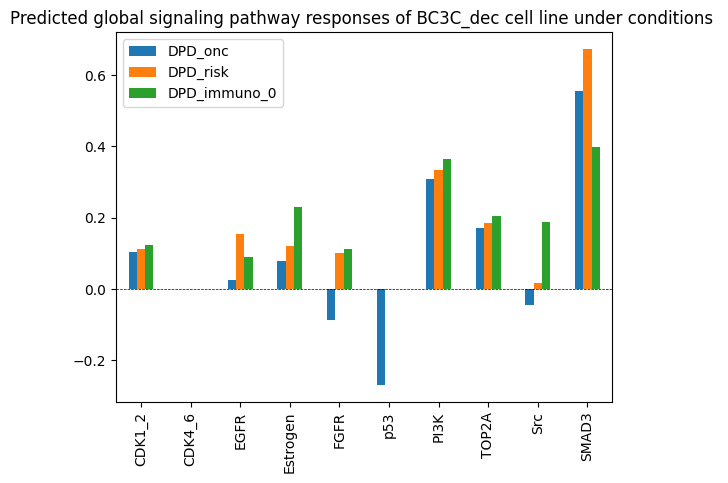

In [20]:
import matplotlib.pyplot as plt
t_df_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted global signaling pathway responses of {cell_line} cell line under conditions ")

In [21]:
display(rm_filt)
rm_subset=rm_filt[['CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'PI3K', 'p53', 'TOP2A','Src','SMAD3']]

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,-1.000000,0.0,0.158616,0.000000,0.207827,0.162486,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
CDK4_6,0.000000,-1.0,0.000000,0.140877,0.000000,0.000000,0.000000,0.000000,0.000000,-0.213214,0.0,0.0,0.0
EGFR,0.000000,0.0,-1.000000,0.000000,0.305886,-0.233815,0.000000,0.000000,-0.061260,0.653994,0.0,0.0,0.0
Estrogen,0.000000,0.0,0.000000,-1.000000,0.257053,0.223030,0.000000,0.000000,0.076738,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.0,0.367534,0.000000,-1.000000,0.173442,0.000000,0.000000,0.000000,0.262083,0.0,0.0,0.0
PI3K,0.341227,0.0,-0.092427,0.336860,0.000000,-1.000000,0.000000,0.557449,-0.114574,0.000000,0.0,0.0,0.0
p53,0.000000,0.0,0.131277,0.000000,0.000000,0.202898,-1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.000000,0.0,-0.151322,0.000000,0.000000,0.204828,0.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.0,0.000000,0.575275,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.0,0.235112,0.000000,0.000000,0.000000,0.000000,0.000000,0.081519,-1.000000,0.0,0.0,0.0


In [22]:
rm_subset=rm_subset.loc[['DPD_onc','DPD_risk',	'DPD_immuno_0']]
rm_subset=rm_subset.T
display(rm_subset)

,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0.000000,0.000000,0.000000
CDK4_6,0.000000,0.000000,0.000000
EGFR,0.000000,0.000000,0.000000
Estrogen,0.000000,0.000000,0.000000
FGFR,-0.136640,0.000000,0.000000
PI3K,0.313585,0.268283,0.253879
p53,-0.268601,0.000000,0.000000
TOP2A,0.000000,0.000000,0.000000
Src,-0.058789,0.000000,0.185032
SMAD3,0.560336,0.544881,0.310164


Text(0.5, 1.0, 'Predicted local signaling pathway responses of BC3C_dec cell line under conditions ')

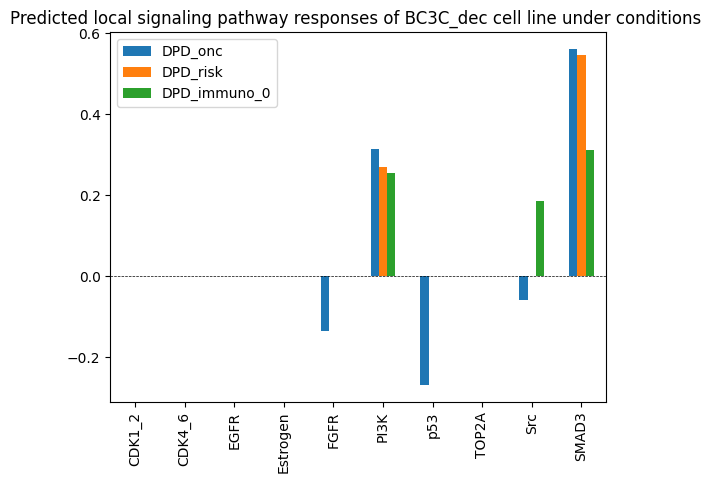

In [23]:
rm_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted local signaling pathway responses of {cell_line} cell line under conditions ")